# Jaccpot GPU Runtime Benchmark (Radix Tree)

This notebook benchmarks Jaccpot runtime on GPU using yggdrax radix-tree settings tuned for throughput.

Included plots:
- `Runtime scaling with particle count (full vs prepared split)`
- `prepare_state component breakdown`

In [1]:
import os

# --- Option A: automatic GPU selection with autocvd ---
USE_AUTOCVD = False
AUTOCVD_NUM_GPUS = 1
AUTOCVD_LEAST_USED = True
AUTOCVD_EXCLUDE = []

# --- Option B: manual selection (set to string like '0' or '0,1') ---
MANUAL_CUDA_VISIBLE_DEVICES = "0,3"  # None #"1,2,3,4,5,6,7,8,9"#None

if MANUAL_CUDA_VISIBLE_DEVICES is not None:
    os.environ["CUDA_VISIBLE_DEVICES"] = MANUAL_CUDA_VISIBLE_DEVICES
    print("Set CUDA_VISIBLE_DEVICES =", os.environ["CUDA_VISIBLE_DEVICES"])
elif USE_AUTOCVD:
    try:
        from autocvd import autocvd

        autocvd(
            num_gpus=AUTOCVD_NUM_GPUS,
            least_used=AUTOCVD_LEAST_USED,
            exclude=AUTOCVD_EXCLUDE,
        )
        print(
            "autocvd selected CUDA_VISIBLE_DEVICES =",
            os.environ.get("CUDA_VISIBLE_DEVICES"),
        )
    except ImportError:
        print(
            "autocvd is not installed. Install it or set MANUAL_CUDA_VISIBLE_DEVICES."
        )
else:
    print(
        "Using existing CUDA visibility:",
        os.environ.get("CUDA_VISIBLE_DEVICES", "<all visible>"),
    )

# GPU memory-fragmentation / graph-memory safeguards.
os.environ.setdefault("TF_GPU_ALLOCATOR", "cuda_malloc_async")
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")
if "--xla_gpu_enable_command_buffer=" not in os.environ.get("XLA_FLAGS", ""):
    existing_xla_flags = os.environ.get("XLA_FLAGS", "").strip()
    command_buffer_off = "--xla_gpu_enable_command_buffer="
    os.environ["XLA_FLAGS"] = (
        f"{existing_xla_flags} {command_buffer_off}".strip()
        if existing_xla_flags
        else command_buffer_off
    )

Set CUDA_VISIBLE_DEVICES = 0,3


In [2]:
import json
import pathlib
import subprocess
import sys
import inspect

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import pandas as pd

REPO_ROOT = pathlib.Path.cwd().resolve()
if not (REPO_ROOT / "jaccpot").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

from jaccpot import (
    FMMAdvancedConfig,
    FMMPreset,
    FarFieldConfig,
    FastMultipoleMethod,
    NearFieldConfig,
    RuntimePolicyConfig,
    TreeConfig,
)
from yggdrax import Tree, compute_tree_geometry
from yggdrax.interactions import DualTreeTraversalConfig, build_interactions_and_neighbors

from examples import benchmark_utils as bench_utils

In [3]:
# GPU sanity check
all_devices = jax.devices()
gpu_devices = [d for d in all_devices if d.platform == "gpu"]
print("JAX backend:", jax.default_backend())
print("Visible devices:", all_devices)
if not gpu_devices:
    raise RuntimeError(
        "No GPU device visible to JAX. Ensure CUDA/ROCm is configured before running this notebook."
    )
print("Using GPU:", gpu_devices[0])

JAX backend: gpu
Visible devices: [CudaDevice(id=0), CudaDevice(id=1)]
Using GPU: cuda:0


## Benchmark Configuration

In [4]:
# Particle-count sweep for scaling plots (includes your target N=131072)
runtime_particle_counts = [8192, 16384, 32768, 65536, 131072, 262144, 524288, 1048576, 2097152, 4194304, 8388608, 16777216]
runtime_leaf_size = 64
runtime_max_order = 4
runtime_runs = 3
runtime_warmup = 1
runtime_isolate_process_per_n = True

# GPU-oriented precision for large-N profiling
runtime_precision = "fp32"
runtime_working_dtype = jnp.float32
runtime_key = jax.random.PRNGKey(0)
softening = 1e-3

# Use the new built-in large-N GPU preset as benchmark baseline.
runtime_fmm_kwargs = dict(
    preset=FMMPreset.LARGE_N_GPU,
    basis="solidfmm",
    precision=runtime_precision,
    theta=0.6,
    softening=softening,
    working_dtype=runtime_working_dtype,
)

## Runtime Collection Helpers

In [5]:
def _evaluate_prepared_kwargs(fmm):
    params = inspect.signature(fmm.evaluate_prepared_state).parameters
    if "jit_traversal" in params:
        return {"jit_traversal": True}
    return {}


def _release_runtime_memory(fmm):
    clear_fn = getattr(fmm, "clear_runtime_caches", None)
    if callable(clear_fn):
        clear_fn(clear_jax_compilation=True)
        return
    if hasattr(fmm, "clear_prepared_state_cache"):
        fmm.clear_prepared_state_cache()
    jax.clear_caches()


def _serialize_fmm_kwargs_for_worker(fmm_kwargs):
    probe_fmm = FastMultipoleMethod(**fmm_kwargs)
    advanced = probe_fmm.advanced
    traversal_cfg = advanced.runtime.traversal_config
    traversal_payload = None
    if traversal_cfg is not None:
        traversal_payload = {
            "process_block": int(traversal_cfg.process_block),
            "max_neighbors_per_leaf": int(traversal_cfg.max_neighbors_per_leaf),
            "max_interactions_per_node": int(traversal_cfg.max_interactions_per_node),
            "max_pair_queue": int(traversal_cfg.max_pair_queue),
        }
    preset_value = fmm_kwargs.get("preset", "fast")
    if hasattr(preset_value, "value"):
        preset_value = preset_value.value
    payload = {
        "preset": str(preset_value),
        "basis": str(fmm_kwargs.get("basis", "solidfmm")),
        "theta": float(fmm_kwargs.get("theta", 0.6)),
        "softening": float(fmm_kwargs.get("softening", 1e-3)),
        "working_dtype": str(jnp.dtype(getattr(probe_fmm._impl, "working_dtype", jnp.float32))),
        "tree_type": str(advanced.tree.tree_type),
        "leaf_target": int(advanced.tree.leaf_target),
        "farfield_rotation": str(advanced.farfield.rotation),
        "farfield_mode": str(advanced.farfield.mode),
        "grouped_interactions": bool(advanced.farfield.grouped_interactions),
        "streamed_far_pairs": advanced.farfield.streamed_far_pairs,
        "mixed_order": bool(advanced.farfield.mixed_order),
        "mixed_order_min_order": advanced.farfield.mixed_order_min_order,
        "nearfield_mode": str(advanced.nearfield.mode),
        "nearfield_edge_chunk_size": int(advanced.nearfield.edge_chunk_size),
        "precompute_scatter_schedules": bool(advanced.nearfield.precompute_scatter_schedules),
        "pair_process_block": (
            None
            if advanced.runtime.pair_process_block is None
            else int(advanced.runtime.pair_process_block)
        ),
        "jit_traversal": bool(advanced.runtime.jit_traversal),
        "traversal_config": traversal_payload,
        "enable_interaction_cache": bool(advanced.runtime.enable_interaction_cache),
        "retain_traversal_result": bool(advanced.runtime.retain_traversal_result),
        "mac_type": str(advanced.mac_type),
    }
    _release_runtime_memory(probe_fmm)
    return payload


def _run_worker_case(mode, *, num_particles, leaf_size, max_order, runs, warmup, dtype, fmm_kwargs):
    worker_script = REPO_ROOT / "examples" / "benchmark_gpu_radix_worker.py"
    payload = _serialize_fmm_kwargs_for_worker(fmm_kwargs)
    cmd = [
        sys.executable,
        str(worker_script),
        "--mode",
        str(mode),
        "--num-particles",
        str(int(num_particles)),
        "--leaf-size",
        str(int(leaf_size)),
        "--max-order",
        str(int(max_order)),
        "--runs",
        str(int(runs)),
        "--warmup",
        str(int(warmup)),
        "--dtype",
        str(jnp.dtype(dtype)),
        "--seed",
        "0",
        "--config-json",
        json.dumps(payload),
    ]
    result = subprocess.run(cmd, check=False, capture_output=True, text=True)
    if result.returncode != 0:
        details = (result.stderr or result.stdout or "").strip()
        raise RuntimeError(f"worker failed (exit={result.returncode}): {details}")
    lines = [line.strip() for line in result.stdout.splitlines() if line.strip()]
    if not lines:
        raise RuntimeError("worker produced no output")
    return json.loads(lines[-1])


def sweep_runtimes(
    particle_counts,
    *,
    leaf_size,
    max_order,
    runs,
    warmup,
    dtype,
    key,
    fmm_kwargs,
    strict=False,
):
    records = []
    use_subprocess = bool(globals().get("runtime_isolate_process_per_n", False))
    fmm = None if use_subprocess else FastMultipoleMethod(**fmm_kwargs)
    current_key = key

    for num_particles in particle_counts:
        try:
            if use_subprocess:
                records.append(
                    _run_worker_case(
                        "sweep",
                        num_particles=num_particles,
                        leaf_size=leaf_size,
                        max_order=max_order,
                        runs=runs,
                        warmup=warmup,
                        dtype=dtype,
                        fmm_kwargs=fmm_kwargs,
                    )
                )
                continue

            positions, masses, current_key = bench_utils.generate_random_distribution(
                num_particles,
                key=current_key,
                dtype=dtype,
            )

            full_timing = bench_utils.time_callable(
                fmm.compute_accelerations,
                positions,
                masses,
                leaf_size=leaf_size,
                max_order=max_order,
                reuse_prepared_state=False,
                warmup=warmup,
                runs=runs,
            )

            prepare_once_timing = bench_utils.time_callable(
                fmm.prepare_state,
                positions,
                masses,
                leaf_size=leaf_size,
                max_order=max_order,
                warmup=warmup,
                runs=runs,
            )
            prepared_state = prepare_once_timing.result

            eval_kwargs = _evaluate_prepared_kwargs(fmm)
            eval_timing = bench_utils.time_callable(
                fmm.evaluate_prepared_state,
                prepared_state,
                warmup=warmup,
                runs=runs,
                **eval_kwargs,
            )

            records.append(
                {
                    "num_particles": num_particles,
                    "mean_seconds": full_timing.mean,
                    "std_seconds": full_timing.std,
                    "prepare_mean_seconds": prepare_once_timing.mean,
                    "prepare_std_seconds": prepare_once_timing.std,
                    "evaluate_mean_seconds": eval_timing.mean,
                    "evaluate_std_seconds": eval_timing.std,
                    "error": "",
                }
            )
        except Exception as exc:
            msg = f"{type(exc).__name__}: {exc}"
            print(f"[sweep_runtimes] N={num_particles} failed: {msg}")
            records.append(
                {
                    "num_particles": num_particles,
                    "mean_seconds": float("nan"),
                    "std_seconds": float("nan"),
                    "prepare_mean_seconds": float("nan"),
                    "prepare_std_seconds": float("nan"),
                    "evaluate_mean_seconds": float("nan"),
                    "evaluate_std_seconds": float("nan"),
                    "error": msg,
                }
            )
            if strict:
                raise
        finally:
            if fmm is not None:
                _release_runtime_memory(fmm)

    return pd.DataFrame(records)


def profile_prepare_components(
    particle_counts,
    *,
    leaf_size,
    max_order,
    dtype,
    key,
    fmm_kwargs,
    runs,
    warmup,
    strict=False,
):
    records = []
    use_subprocess = bool(globals().get("runtime_isolate_process_per_n", False))
    fmm = None if use_subprocess else FastMultipoleMethod(**fmm_kwargs)
    current_key = key

    if not use_subprocess:
        tree_type = str(getattr(fmm._impl, "tree_type", "radix"))
        tree_mode = str(getattr(fmm._impl, "tree_build_mode", "lbvh"))
        ygg_build_mode = "fixed_depth" if tree_mode == "fixed_depth" else "adaptive"
        theta_val = float(getattr(fmm._impl, "theta", fmm_kwargs.get("theta", 0.6)))
        traversal_cfg = fmm.advanced.runtime.traversal_config
        mac_type = str(getattr(fmm, "mac_type", "dehnen"))
        dehnen_radius_scale = float(getattr(fmm._impl, "dehnen_radius_scale", 1.0))

    for num_particles in particle_counts:
        try:
            if use_subprocess:
                records.append(
                    _run_worker_case(
                        "prepare",
                        num_particles=num_particles,
                        leaf_size=leaf_size,
                        max_order=max_order,
                        runs=runs,
                        warmup=warmup,
                        dtype=dtype,
                        fmm_kwargs=fmm_kwargs,
                    )
                )
                continue

            positions, masses, current_key = bench_utils.generate_random_distribution(
                num_particles,
                key=current_key,
                dtype=dtype,
            )

            tree_timing = bench_utils.time_callable(
                Tree.from_particles,
                positions,
                masses,
                tree_type=tree_type,
                build_mode=ygg_build_mode,
                return_reordered=True,
                leaf_size=int(leaf_size),
                warmup=warmup,
                runs=runs,
            )

            tree = Tree.from_particles(
                positions,
                masses,
                tree_type=tree_type,
                build_mode=ygg_build_mode,
                return_reordered=True,
                leaf_size=int(leaf_size),
            )
            geometry = compute_tree_geometry(tree, tree.positions_sorted)

            interactions_timing = bench_utils.time_callable(
                build_interactions_and_neighbors,
                tree,
                geometry,
                theta=theta_val,
                traversal_config=traversal_cfg,
                mac_type=mac_type,
                dehnen_radius_scale=dehnen_radius_scale,
                warmup=warmup,
                runs=runs,
            )

            prepare_timing = bench_utils.time_callable(
                fmm.prepare_state,
                positions,
                masses,
                leaf_size=int(leaf_size),
                max_order=max_order,
                warmup=warmup,
                runs=runs,
            )

            residual = max(
                float(prepare_timing.mean)
                - float(tree_timing.mean)
                - float(interactions_timing.mean),
                0.0,
            )
            records.append(
                {
                    "num_particles": num_particles,
                    "tree_build_mean_seconds": float(tree_timing.mean),
                    "interactions_mean_seconds": float(interactions_timing.mean),
                    "upward_mean_seconds": residual,
                    "downward_mean_seconds": 0.0,
                    "prepare_component_sum_seconds": float(prepare_timing.mean),
                    "error": "",
                }
            )
        except Exception as exc:
            msg = f"{type(exc).__name__}: {exc}"
            print(f"[profile_prepare_components] N={num_particles} failed: {msg}")
            records.append(
                {
                    "num_particles": num_particles,
                    "tree_build_mean_seconds": float("nan"),
                    "upward_mean_seconds": float("nan"),
                    "interactions_mean_seconds": float("nan"),
                    "downward_mean_seconds": float("nan"),
                    "prepare_component_sum_seconds": float("nan"),
                    "error": msg,
                }
            )
            if strict:
                raise
        finally:
            if fmm is not None:
                _release_runtime_memory(fmm)

    return pd.DataFrame(records)

## Runtime Scaling (Full vs Prepared Split)

In [6]:
runtime_df = sweep_runtimes(
    runtime_particle_counts,
    leaf_size=runtime_leaf_size,
    max_order=runtime_max_order,
    runs=runtime_runs,
    warmup=runtime_warmup,
    dtype=runtime_working_dtype,
    key=runtime_key,
    fmm_kwargs=runtime_fmm_kwargs,
)
runtime_df_sorted = runtime_df.sort_values("num_particles")
runtime_df_sorted

[sweep_runtimes] N=16777216 failed: RuntimeError: worker failed (exit=-11): E0307 02:08:50.892338  477847 gpu_hlo_schedule.cc:868] The byte size of input/output arguments (105553116266496) exceeds the base limit (33828215193). This indicates an error in the calculation!
E0307 02:08:50.892343  477896 gpu_hlo_schedule.cc:868] The byte size of input/output arguments (105553116266496) exceeds the base limit (33828215193). This indicates an error in the calculation!
E0307 02:08:50.893300  477867 gpu_hlo_schedule.cc:868] The byte size of input/output arguments (57200374448144) exceeds the base limit (33828215193). This indicates an error in the calculation!
W0307 02:08:50.962208  477908 bfc_allocator.cc:311] Allocator (GPU_0_bfc) ran out of memory trying to allocate 12.02GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
W0307 02:08:50.966613  477893 bfc_allocator.cc:311] Allocator

,num_particles,mean_seconds,std_seconds,prepare_mean_seconds,prepare_std_seconds,evaluate_mean_seconds,evaluate_std_seconds,error
0,8192,11.908000,1.491248,3.091429,0.796544,8.226128,0.046970,
1,16384,32.414750,2.103876,5.392814,0.219302,27.647266,0.594215,
2,32768,69.708952,0.329493,5.429957,0.166563,64.042025,0.068420,
3,65536,168.884718,0.813514,5.325809,0.114009,161.285143,0.314232,
4,131072,414.843017,1.115852,10.151424,0.636449,404.553631,0.815698,
5,262144,NaN,NaN,NaN,NaN,NaN,NaN,JaxRuntimeError: RESOURCE_EXHAUSTED: Out of me...
6,524288,NaN,NaN,NaN,NaN,NaN,NaN,JaxRuntimeError: RESOURCE_EXHAUSTED: Out of me...
7,1048576,NaN,NaN,NaN,NaN,NaN,NaN,JaxRuntimeError: RESOURCE_EXHAUSTED: Out of me...
8,2097152,NaN,NaN,NaN,NaN,NaN,NaN,JaxRuntimeError: RESOURCE_EXHAUSTED: Out of me...
9,4194304,NaN,NaN,NaN,NaN,NaN,NaN,JaxRuntimeError: RESOURCE_EXHAUSTED: Out of me...


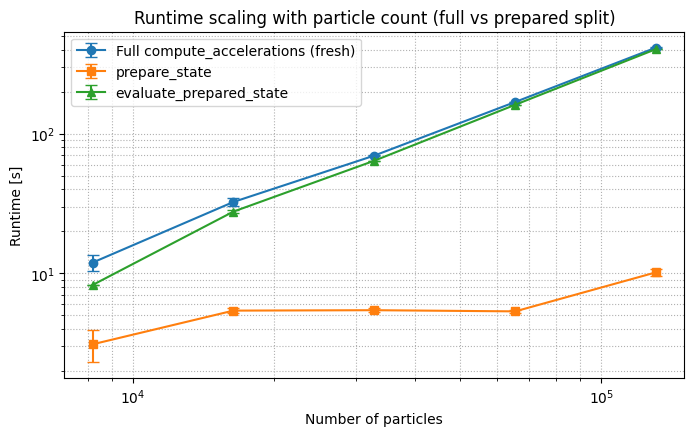

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.5))

ax.errorbar(
    runtime_df_sorted["num_particles"],
    runtime_df_sorted["mean_seconds"],
    yerr=runtime_df_sorted["std_seconds"],
    fmt="o-",
    capsize=4,
    label="Full compute_accelerations (fresh)",
)
ax.errorbar(
    runtime_df_sorted["num_particles"],
    runtime_df_sorted["prepare_mean_seconds"],
    yerr=runtime_df_sorted["prepare_std_seconds"],
    fmt="s-",
    capsize=4,
    label="prepare_state",
)
ax.errorbar(
    runtime_df_sorted["num_particles"],
    runtime_df_sorted["evaluate_mean_seconds"],
    yerr=runtime_df_sorted["evaluate_std_seconds"],
    fmt="^-",
    capsize=4,
    label="evaluate_prepared_state",
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Number of particles")
ax.set_ylabel("Runtime [s]")
ax.set_title("Runtime scaling with particle count (full vs prepared split)")
ax.grid(True, which="both", linestyle=":", linewidth=0.8)
ax.legend()
plt.show()

## Prepare-State Component Breakdown

In [8]:
runtime_component_df = profile_prepare_components(
    runtime_particle_counts,
    leaf_size=runtime_leaf_size,
    max_order=runtime_max_order,
    dtype=runtime_working_dtype,
    key=runtime_key,
    fmm_kwargs=runtime_fmm_kwargs,
    runs=max(1, runtime_runs),
    warmup=runtime_warmup,
)
runtime_component_df

[profile_prepare_components] N=16777216 failed: RuntimeError: worker failed (exit=-11): E0307 02:30:46.208684  509408 gpu_hlo_schedule.cc:868] The byte size of input/output arguments (105553116266496) exceeds the base limit (33828215193). This indicates an error in the calculation!
E0307 02:30:46.208724  509427 gpu_hlo_schedule.cc:868] The byte size of input/output arguments (105553116266496) exceeds the base limit (33828215193). This indicates an error in the calculation!
E0307 02:30:46.209567  509444 gpu_hlo_schedule.cc:868] The byte size of input/output arguments (57200374448144) exceeds the base limit (33828215193). This indicates an error in the calculation!
W0307 02:30:46.284687  509426 bfc_allocator.cc:311] Allocator (GPU_0_bfc) ran out of memory trying to allocate 12.02GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
W0307 02:30:46.287616  509443 bfc_allocator.cc:31

,num_particles,tree_build_mean_seconds,interactions_mean_seconds,upward_mean_seconds,downward_mean_seconds,prepare_component_sum_seconds,error
0,8192,1.732020,0.027657,2.634805,0.0,4.394482,
1,16384,1.642461,0.042739,2.391099,0.0,4.076298,
2,32768,1.445892,0.068582,3.789201,0.0,5.303675,
3,65536,1.782217,0.077679,3.663747,0.0,5.523642,
4,131072,1.538927,0.120083,7.847928,0.0,9.506938,
5,262144,NaN,NaN,NaN,NaN,NaN,JaxRuntimeError: RESOURCE_EXHAUSTED: Out of me...
6,524288,NaN,NaN,NaN,NaN,NaN,JaxRuntimeError: RESOURCE_EXHAUSTED: Out of me...
7,1048576,NaN,NaN,NaN,NaN,NaN,JaxRuntimeError: RESOURCE_EXHAUSTED: Out of me...
8,2097152,NaN,NaN,NaN,NaN,NaN,JaxRuntimeError: RESOURCE_EXHAUSTED: Out of me...
9,4194304,NaN,NaN,NaN,NaN,NaN,JaxRuntimeError: RESOURCE_EXHAUSTED: Out of me...


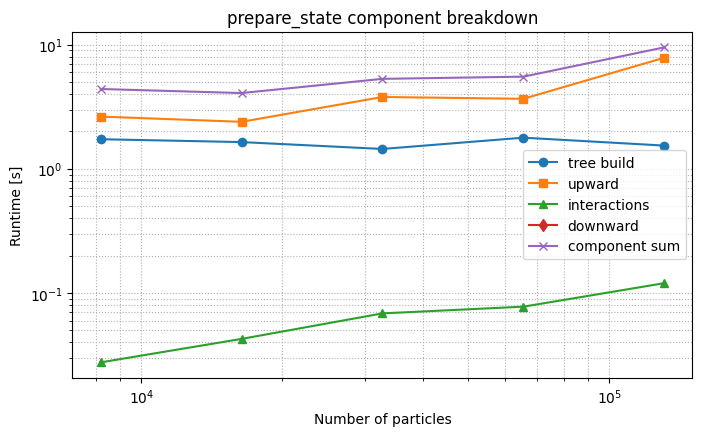

In [9]:
runtime_component_sorted = runtime_component_df.sort_values("num_particles")

fig, ax = plt.subplots(figsize=(8, 4.5))
for col, label, marker in [
    ("tree_build_mean_seconds", "tree build", "o"),
    ("upward_mean_seconds", "upward", "s"),
    ("interactions_mean_seconds", "interactions", "^"),
    ("downward_mean_seconds", "downward", "d"),
    ("prepare_component_sum_seconds", "component sum", "x"),
]:
    ax.plot(
        runtime_component_sorted["num_particles"],
        runtime_component_sorted[col],
        marker=marker,
        label=label,
    )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Number of particles")
ax.set_ylabel("Runtime [s]")
ax.set_title("prepare_state component breakdown")
ax.grid(True, which="both", linestyle=":", linewidth=0.8)
ax.legend()
plt.show()

## Notes

- This notebook is GPU-focused and will fail early if no GPU is visible to JAX.
- The traversal configuration is fixed to:
  - `leaf_size=64`
  - `process_block=256`
  - `max_neighbors_per_leaf=4096`
  - `max_interactions_per_node=1024`
  - `max_pair_queue=262_144`
- The scaling sweep includes `N=131072` as requested.